In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../outputs/domain_wise.csv")

df_2 = pd.read_csv("../data/asample2_withlag.csv")

In [8]:
Aset1 = [col for col in df_2.columns if "Aset1" in col]
Aset2 = [col for col in df_2.columns if "Aset2" in col]
Bset1 = [col for col in df_2.columns if "Bset1" in col]
Bset2 = [col for col in df_2.columns if "Bset2" in col]

In [9]:
summary = (
    df.groupby(["data","k"])
    .agg(
        mean_r2 = ("r2", "mean"),
        sd_r2 = ("r2", "std"),
        mean_mse=("mse", "mean"),
        sd_mse=("mse", "std"),
    )
    .reset_index()
)

In [10]:
# total number of features in each dataset
feature_counts = {
    "Aset1": len(Aset1),
    "Aset2": len(Aset2),
    "Bset1": len(Bset1),
    "Bset2": len(Bset2),
}

# convert k -> percentage of full feature set
summary["pct_features"] = (
    summary.apply(
        lambda row: row["k"] / feature_counts[row["data"]] * 100,
        axis=1
    )
)

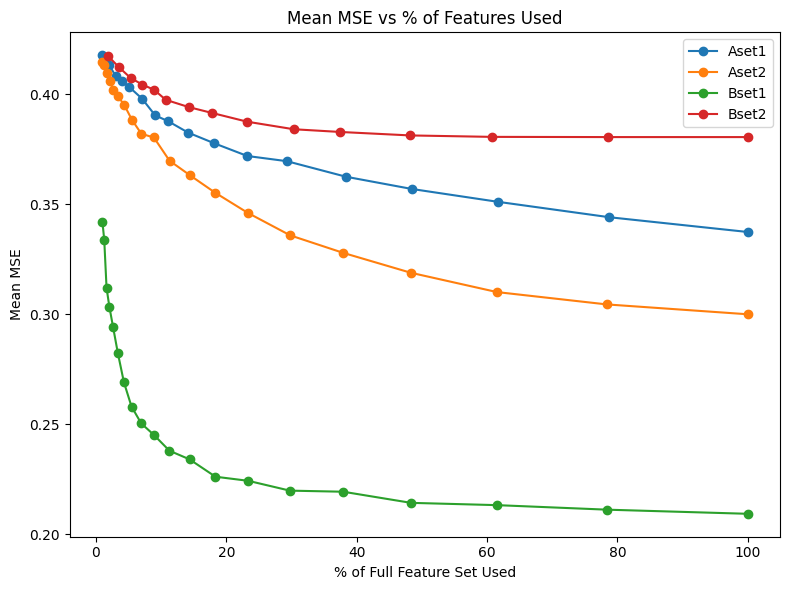

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, group in summary.groupby("data"):
    group = group.sort_values("pct_features")

    plt.plot(
        group["pct_features"],
        group["mean_mse"],
        marker="o",
        label=name
    )

plt.xlabel("% of Full Feature Set Used")
plt.ylabel("Mean MSE")
plt.title("Mean MSE vs % of Features Used")
plt.legend()
plt.tight_layout()

plt.show()